# 04 - Customer Segmentation

# 04 - Customer Segmentation Analysis

## Tujuan

Notebook ini digunakan untuk mengubah hasil RFM Analysis menjadi
customer segment yang dapat digunakan untuk kebutuhan bisnis.

Analisis mencakup:

1. Load RFM dataset.
2. Menentukan aturan customer segmentation.
3. Membentuk customer segment.
4. Memvalidasi hasil segmentasi.
5. Menganalisis karakteristik setiap segment.
6. Mengukur kontribusi revenue setiap segment.
7. Menggabungkan segment dengan customer profile.
8. Menyusun business insight.
9. Menentukan rekomendasi strategi per segment.
10. Mengekspor hasil segmentasi untuk Power BI.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load RFM Dataset

In [3]:
rfm = pd.read_csv(
    "../data/processed/customer_rfm.csv",
    parse_dates=["last_purchase"]
)

In [4]:
rfm.head()

,customer_id,last_purchase,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,rfm_total_score
0,CUST00001,2025-12-13,19,27,14614700,4,5,5,455,14
1,CUST00002,2025-12-13,19,16,11428800,4,4,5,445,13
2,CUST00004,2025-05-29,217,6,3279850,1,2,3,123,6
3,CUST00005,2025-11-10,52,15,10582650,3,4,4,344,11
4,CUST00006,2025-12-04,28,9,6056100,4,3,4,434,11


In [5]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customer_id      1898 non-null   object        
 1   last_purchase    1898 non-null   datetime64[ns]
 2   recency          1898 non-null   int64         
 3   frequency        1898 non-null   int64         
 4   monetary         1898 non-null   int64         
 5   r_score          1898 non-null   int64         
 6   f_score          1898 non-null   int64         
 7   m_score          1898 non-null   int64         
 8   rfm_score        1898 non-null   int64         
 9   rfm_total_score  1898 non-null   int64         
dtypes: datetime64[ns](1), int64(8), object(1)
memory usage: 148.4+ KB


Validasi sebelum segmentasi

In [6]:
print(f"Total Customers : {len(rfm):,}")
print(
    f"Unique Customers: "
    f"{rfm['customer_id'].nunique():,}"
)

Total Customers : 1,898
Unique Customers: 1,898


In [7]:
rfm[
    [
        "recency",
        "frequency",
        "monetary",
        "r_score",
        "f_score",
        "m_score"
    ]
].describe()

,recency,frequency,monetary,r_score,f_score,m_score
count,1898.000000,1898.000000,1.898000e+03,1898.000000,1898.000000,1898.000000
mean,101.113804,13.171760,6.297440e+06,3.000000,3.000000,3.000000
std,131.963944,11.996222,6.466738e+06,1.414959,1.414959,1.414959
min,1.000000,1.000000,1.680000e+04,1.000000,1.000000,1.000000
25%,18.000000,5.000000,1.572312e+06,2.000000,2.000000,2.000000
50%,48.000000,9.000000,4.302225e+06,3.000000,3.000000,3.000000
75%,125.750000,19.000000,9.065875e+06,4.000000,4.000000,4.000000
max,727.000000,108.000000,5.875395e+07,5.000000,5.000000,5.000000


fungsi segmentation

In [8]:
def assign_segment(row):

    r = row["r_score"]
    f = row["f_score"]
    m = row["m_score"]

    if (
        r >= 4
        and f >= 4
        and m >= 4
    ):
        return "Champions"

    elif (
        r >= 3
        and f >= 4
    ):
        return "Loyal Customers"

    elif (
        r >= 4
        and f >= 2
        and f <= 3
    ):
        return "Potential Loyalists"

    elif (
        r == 5
        and f == 1
    ):
        return "New Customers"

    elif (
        r <= 2
        and f >= 3
    ):
        return "At Risk"

    elif (
        r <= 2
        and f <= 2
        and m <= 2
    ):
        return "Hibernating"

    else:
        return "Needs Attention"

Terapkan segmentasi

In [9]:
rfm["segment"] = rfm.apply(
    assign_segment,
    axis=1
)

In [10]:
rfm[
    [
        "customer_id",
        "recency",
        "frequency",
        "monetary",
        "r_score",
        "f_score",
        "m_score",
        "rfm_score",
        "segment"
    ]
].head(20)

,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,segment
0,CUST00001,19,27,14614700,4,5,5,455,Champions
1,CUST00002,19,16,11428800,4,4,5,445,Champions
2,CUST00004,217,6,3279850,1,2,3,123,Needs Attention
3,CUST00005,52,15,10582650,3,4,4,344,Loyal Customers
4,CUST00006,28,9,6056100,4,3,4,434,Potential Loyalists
5,CUST00007,43,12,9159000,3,3,4,334,Needs Attention
6,CUST00008,191,4,3418350,1,1,3,113,Needs Attention
7,CUST00009,496,1,90750,1,1,1,111,Hibernating
8,CUST00010,652,1,235000,1,1,1,111,Hibernating
9,CUST00012,40,29,11246750,3,5,5,355,Loyal Customers


Hitung jumlah customer per segment

In [11]:
segment_counts = (
    rfm["segment"]
    .value_counts()
)

segment_counts

segment
Hibernating            458
Champions              430
Needs Attention        295
Loyal Customers        245
At Risk                232
Potential Loyalists    218
New Customers           20
Name: count, dtype: int64

DataFrame segment distribution

In [12]:
segment_distribution = (
    rfm["segment"]
    .value_counts()
    .reset_index()
)

segment_distribution.columns = [
    "segment",
    "customer_count"
]

In [13]:
segment_distribution[
    "customer_percentage"
] = (
    segment_distribution[
        "customer_count"
    ]
    / len(rfm)
    * 100
)

In [14]:
segment_distribution

,segment,customer_count,customer_percentage
0,Hibernating,458,24.130664
1,Champions,430,22.655427
2,Needs Attention,295,15.542677
3,Loyal Customers,245,12.908325
4,At Risk,232,12.223393
5,Potential Loyalists,218,11.485774
6,New Customers,20,1.053741


Validasi total customer

In [15]:
segment_distribution[
    "customer_count"
].sum()

np.int64(1898)

In [16]:
len(rfm)

1898

In [17]:
assert (
    segment_distribution[
        "customer_count"
    ].sum()
    == len(rfm)
)

Pastikan tidak ada segment kosong

In [18]:
rfm["segment"].isna().sum()

np.int64(0)

In [19]:
assert (
    rfm["segment"]
    .isna()
    .sum()
    == 0
)

Visualisasi Customer Distribution

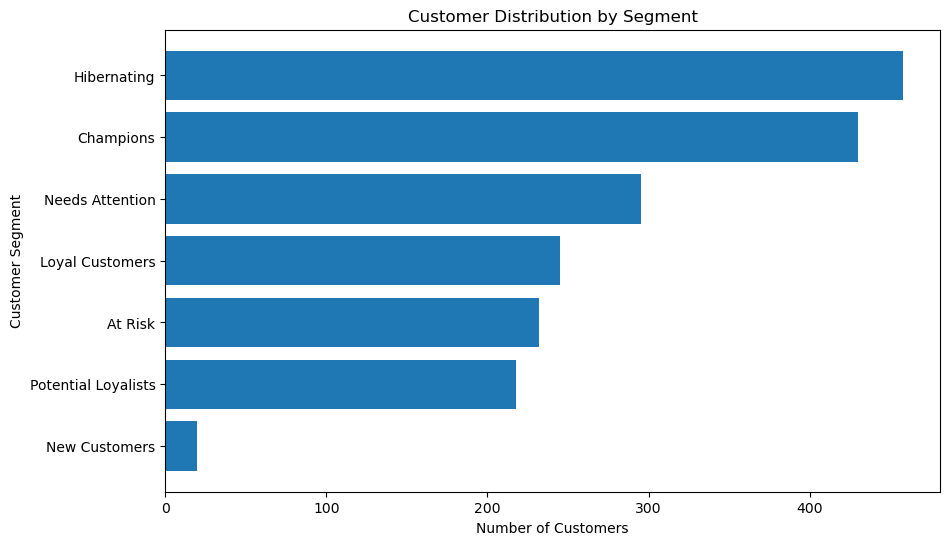

In [21]:
segment_plot = (
    segment_distribution
    .sort_values(
        "customer_count"
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    segment_plot["segment"],
    segment_plot["customer_count"]
)

plt.title(
    "Customer Distribution by Segment"
)

plt.xlabel(
    "Number of Customers"
)

plt.ylabel(
    "Customer Segment"
)

plt.show()

Segment Summary

In [22]:
segment_summary = (
    rfm
    .groupby("segment")
    .agg(

        customers=(
            "customer_id",
            "nunique"
        ),

        avg_recency=(
            "recency",
            "mean"
        ),

        avg_frequency=(
            "frequency",
            "mean"
        ),

        total_monetary=(
            "monetary",
            "sum"
        ),

        avg_monetary=(
            "monetary",
            "mean"
        )
    )
    .reset_index()
)

In [23]:
segment_summary

,segment,customers,avg_recency,avg_frequency,total_monetary,avg_monetary
0,At Risk,232,128.012931,12.625000,1427080200,6.151208e+06
1,Champions,430,14.172093,28.597674,6046400050,1.406140e+07
2,Hibernating,458,259.543668,3.181223,454510500,9.923810e+05
3,Loyal Customers,245,38.367347,19.040816,2004631650,8.182170e+06
4,Needs Attention,295,82.033898,6.200000,1108771800,3.758548e+06
5,New Customers,20,7.150000,2.400000,20907250,1.045362e+06
6,Potential Loyalists,218,16.087156,8.142202,890239500,4.083667e+06


persentase customer

In [24]:
segment_summary[
    "customer_percentage"
] = (
    segment_summary[
        "customers"
    ]
    / len(rfm)
    * 100
)

revenue contribution

In [25]:
total_monetary = (
    rfm["monetary"].sum()
)

In [26]:
segment_summary[
    "revenue_percentage"
] = (
    segment_summary[
        "total_monetary"
    ]
    / total_monetary
    * 100
)

In [27]:
segment_summary.sort_values(
    "total_monetary",
    ascending=False
)

,segment,customers,avg_recency,avg_frequency,total_monetary,avg_monetary,customer_percentage,revenue_percentage
1,Champions,430,14.172093,28.597674,6046400050,1.406140e+07,22.655427,50.586734
3,Loyal Customers,245,38.367347,19.040816,2004631650,8.182170e+06,12.908325,16.771594
0,At Risk,232,128.012931,12.625000,1427080200,6.151208e+06,12.223393,11.939555
4,Needs Attention,295,82.033898,6.200000,1108771800,3.758548e+06,15.542677,9.276453
6,Potential Loyalists,218,16.087156,8.142202,890239500,4.083667e+06,11.485774,7.448119
2,Hibernating,458,259.543668,3.181223,454510500,9.923810e+05,24.130664,3.802627
5,New Customers,20,7.150000,2.400000,20907250,1.045362e+06,1.053741,0.174919


Format hanya untuk display

In [28]:
segment_summary_display = (
    segment_summary.copy()
)

segment_summary_display[
    "avg_recency"
] = (
    segment_summary_display[
        "avg_recency"
    ].round(1)
)

segment_summary_display[
    "avg_frequency"
] = (
    segment_summary_display[
        "avg_frequency"
    ].round(1)
)

segment_summary_display[
    "customer_percentage"
] = (
    segment_summary_display[
        "customer_percentage"
    ].round(2)
)

segment_summary_display[
    "revenue_percentage"
] = (
    segment_summary_display[
        "revenue_percentage"
    ].round(2)
)

segment_summary_display

,segment,customers,avg_recency,avg_frequency,total_monetary,avg_monetary,customer_percentage,revenue_percentage
0,At Risk,232,128.0,12.6,1427080200,6.151208e+06,12.22,11.94
1,Champions,430,14.2,28.6,6046400050,1.406140e+07,22.66,50.59
2,Hibernating,458,259.5,3.2,454510500,9.923810e+05,24.13,3.80
3,Loyal Customers,245,38.4,19.0,2004631650,8.182170e+06,12.91,16.77
4,Needs Attention,295,82.0,6.2,1108771800,3.758548e+06,15.54,9.28
5,New Customers,20,7.2,2.4,20907250,1.045362e+06,1.05,0.17
6,Potential Loyalists,218,16.1,8.1,890239500,4.083667e+06,11.49,7.45


Revenue by Segment

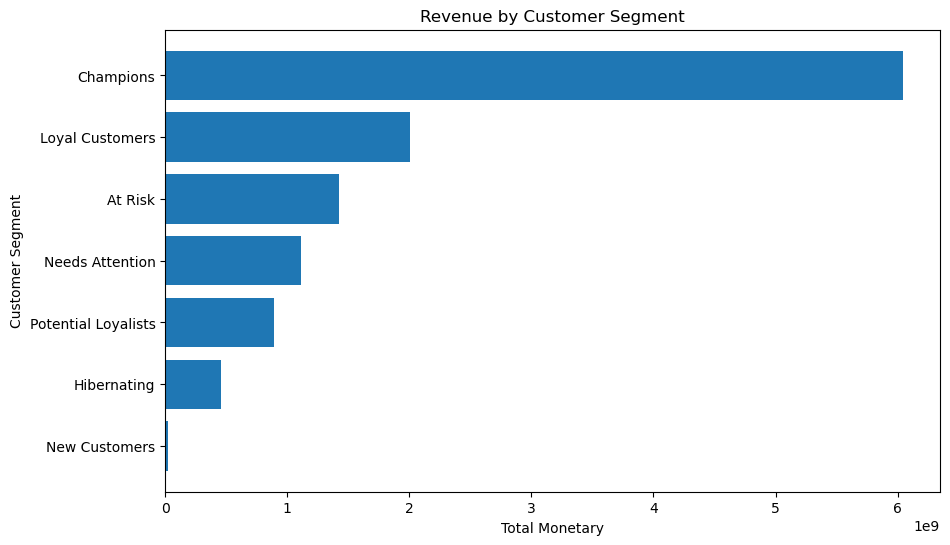

In [29]:
revenue_segment = (
    segment_summary
    .sort_values(
        "total_monetary"
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    revenue_segment["segment"],
    revenue_segment["total_monetary"]
)

plt.title(
    "Revenue by Customer Segment"
)

plt.xlabel(
    "Total Monetary"
)

plt.ylabel(
    "Customer Segment"
)

plt.show()

Customer % vs Revenue %

In [30]:
segment_comparison = (
    segment_summary[
        [
            "segment",
            "customer_percentage",
            "revenue_percentage"
        ]
    ]
    .sort_values(
        "revenue_percentage",
        ascending=False
    )
)

segment_comparison

,segment,customer_percentage,revenue_percentage
1,Champions,22.655427,50.586734
3,Loyal Customers,12.908325,16.771594
0,At Risk,12.223393,11.939555
4,Needs Attention,15.542677,9.276453
6,Potential Loyalists,11.485774,7.448119
2,Hibernating,24.130664,3.802627
5,New Customers,1.053741,0.174919


Revenue Efficiency sederhana

In [31]:
segment_summary[
    "revenue_customer_ratio"
] = (
    segment_summary[
        "revenue_percentage"
    ]
    /
    segment_summary[
        "customer_percentage"
    ]
)

Analisis Champions

In [32]:
champions = rfm[
    rfm["segment"]
    == "Champions"
].copy()

In [33]:
champions[
    [
        "customer_id",
        "recency",
        "frequency",
        "monetary",
        "rfm_score"
    ]
].sort_values(
    "monetary",
    ascending=False
).head(20)

,customer_id,recency,frequency,monetary,rfm_score
981,CUST01047,1,108,58753950,555
694,CUST00739,4,66,43092250,555
1554,CUST01644,4,60,41219900,555
154,CUST00163,10,42,40664250,555
1759,CUST01856,25,56,40596000,455
563,CUST00599,31,61,40272100,455
1847,CUST01949,23,68,35547800,455
1835,CUST01937,14,68,35537000,455
1170,CUST01242,2,66,31443650,555
1575,CUST01665,1,39,31430950,555


In [34]:
print(
    f"Champions Customers : "
    f"{len(champions):,}"
)

print(
    f"Champions Revenue   : "
    f"Rp{champions['monetary'].sum():,.0f}"
)

Champions Customers : 430
Champions Revenue   : Rp6,046,400,050


Analisis Loyal Customers

In [35]:
loyal = rfm[
    rfm["segment"]
    == "Loyal Customers"
].copy()

In [37]:
loyal[
    [
        "customer_id",
        "recency",
        "frequency",
        "monetary",
        "rfm_score"
    ]
].sort_values(
    "monetary",
    ascending=False
).head()

,customer_id,recency,frequency,monetary,rfm_score
41,CUST00044,60,48,33553350,355
1216,CUST01288,61,37,28930750,355
1249,CUST01324,60,34,24338400,355
790,CUST00843,52,34,23307350,355
723,CUST00770,57,21,20135750,345


At Risk

In [39]:
at_risk = rfm[
    rfm["segment"]
    == "At Risk"
].copy()

In [40]:
at_risk[
    [
        "customer_id",
        "recency",
        "frequency",
        "monetary",
        "rfm_score"
    ]
].sort_values(
    "monetary",
    ascending=False
).head(20)

,customer_id,recency,frequency,monetary,rfm_score
48,CUST00051,96,11,19155800,235
554,CUST00589,92,21,18357650,245
1783,CUST01881,97,14,17640650,245
495,CUST00526,82,18,17411250,245
244,CUST00264,101,12,16761050,235
1617,CUST01711,187,8,16604300,135
1866,CUST01969,74,43,16208100,255
157,CUST00166,92,33,15840400,255
1164,CUST01236,110,8,15683850,235
37,CUST00040,88,15,15505900,245


Historical value At Risk

In [41]:
at_risk_value = (
    at_risk["monetary"].sum()
)

at_risk_pct = (
    at_risk_value
    / total_monetary
    * 100
)

print(
    f"At Risk Historical Value : "
    f"Rp{at_risk_value:,.0f}"
)

print(
    f"Revenue Contribution     : "
    f"{at_risk_pct:.2f}%"
)

At Risk Historical Value : Rp1,427,080,200
Revenue Contribution     : 11.94%


Hibernating

In [42]:
hibernating = rfm[
    rfm["segment"]
    == "Hibernating"
].copy()

In [43]:
hibernating[
    [
        "customer_id",
        "recency",
        "frequency",
        "monetary",
        "rfm_score"
    ]
].sort_values(
    "recency",
    ascending=False
).head(20)

,customer_id,recency,frequency,monetary,rfm_score
1574,CUST01664,727,1,168300,111
1248,CUST01323,726,1,234000,111
615,CUST00652,718,1,27900,111
230,CUST00248,717,1,168000,111
178,CUST00189,715,1,86400,111
847,CUST00902,712,1,34000,111
1592,CUST01683,697,1,774400,111
916,CUST00975,696,1,977000,111
575,CUST00611,687,1,38000,111
569,CUST00605,677,2,1339000,112


Jangan samakan Hibernating dengan At Risk

Needs Attention

In [45]:
needs_attention = rfm[
    rfm["segment"]
    == "Needs Attention"
].copy()

In [46]:
needs_attention[
    [
        "recency",
        "frequency",
        "monetary"
    ]
].describe()

,recency,frequency,monetary
count,295.000000,295.000000,2.950000e+02
mean,82.033898,6.200000,3.758548e+06
std,79.503897,2.823131,2.681777e+06
min,14.000000,1.000000,3.420000e+04
25%,42.000000,4.000000,1.603100e+06
50%,55.000000,6.000000,3.418350e+06
75%,70.500000,8.000000,5.100825e+06
max,558.000000,12.000000,1.747090e+07


Evaluasi ukuran Needs Attention

In [47]:
needs_attention_pct = (
    len(needs_attention)
    / len(rfm)
    * 100
)

print(
    f"Needs Attention: "
    f"{needs_attention_pct:.2f}%"
)

Needs Attention: 15.54%


Ringkasan karakteristik semua segment

In [48]:
segment_summary = (
    segment_summary
    .sort_values(
        "total_monetary",
        ascending=False
    )
    .reset_index(drop=True)
)

segment_summary

,segment,customers,avg_recency,avg_frequency,total_monetary,avg_monetary,customer_percentage,revenue_percentage,revenue_customer_ratio
0,Champions,430,14.172093,28.597674,6046400050,1.406140e+07,22.655427,50.586734,2.232875
1,Loyal Customers,245,38.367347,19.040816,2004631650,8.182170e+06,12.908325,16.771594,1.299285
2,At Risk,232,128.012931,12.625000,1427080200,6.151208e+06,12.223393,11.939555,0.976779
3,Needs Attention,295,82.033898,6.200000,1108771800,3.758548e+06,15.542677,9.276453,0.596838
4,Potential Loyalists,218,16.087156,8.142202,890239500,4.083667e+06,11.485774,7.448119,0.648465
5,Hibernating,458,259.543668,3.181223,454510500,9.923810e+05,24.130664,3.802627,0.157585
6,New Customers,20,7.150000,2.400000,20907250,1.045362e+06,1.053741,0.174919,0.165998


Tambahkan Median

In [49]:
segment_analysis = (
    rfm
    .groupby("segment")
    .agg(

        customers=(
            "customer_id",
            "nunique"
        ),

        avg_recency=(
            "recency",
            "mean"
        ),

        median_recency=(
            "recency",
            "median"
        ),

        avg_frequency=(
            "frequency",
            "mean"
        ),

        median_frequency=(
            "frequency",
            "median"
        ),

        total_monetary=(
            "monetary",
            "sum"
        ),

        avg_monetary=(
            "monetary",
            "mean"
        ),

        median_monetary=(
            "monetary",
            "median"
        )
    )
    .reset_index()
)

Tambahkan contribution

In [50]:
segment_analysis[
    "customer_percentage"
] = (
    segment_analysis["customers"]
    / len(rfm)
    * 100
)

In [51]:
segment_analysis[
    "revenue_percentage"
] = (
    segment_analysis["total_monetary"]
    / rfm["monetary"].sum()
    * 100
)

In [52]:
segment_analysis = (
    segment_analysis
    .sort_values(
        "total_monetary",
        ascending=False
    )
)

segment_analysis

,segment,customers,avg_recency,median_recency,avg_frequency,median_frequency,total_monetary,avg_monetary,median_monetary,customer_percentage,revenue_percentage
1,Champions,430,14.172093,12.0,28.597674,25.0,6046400050,1.406140e+07,12255675.0,22.655427,50.586734
3,Loyal Customers,245,38.367347,40.0,19.040816,17.0,2004631650,8.182170e+06,6196650.0,12.908325,16.771594
0,At Risk,232,128.012931,111.0,12.625000,11.0,1427080200,6.151208e+06,4824275.0,12.223393,11.939555
4,Needs Attention,295,82.033898,55.0,6.200000,6.0,1108771800,3.758548e+06,3418350.0,15.542677,9.276453
6,Potential Loyalists,218,16.087156,16.0,8.142202,8.0,890239500,4.083667e+06,3410975.0,11.485774,7.448119
2,Hibernating,458,259.543668,200.5,3.181223,3.0,454510500,9.923810e+05,786650.0,24.130664,3.802627
5,New Customers,20,7.150000,7.0,2.400000,2.0,20907250,1.045362e+06,638775.0,1.053741,0.174919


Visualisasi Revenue Contribution

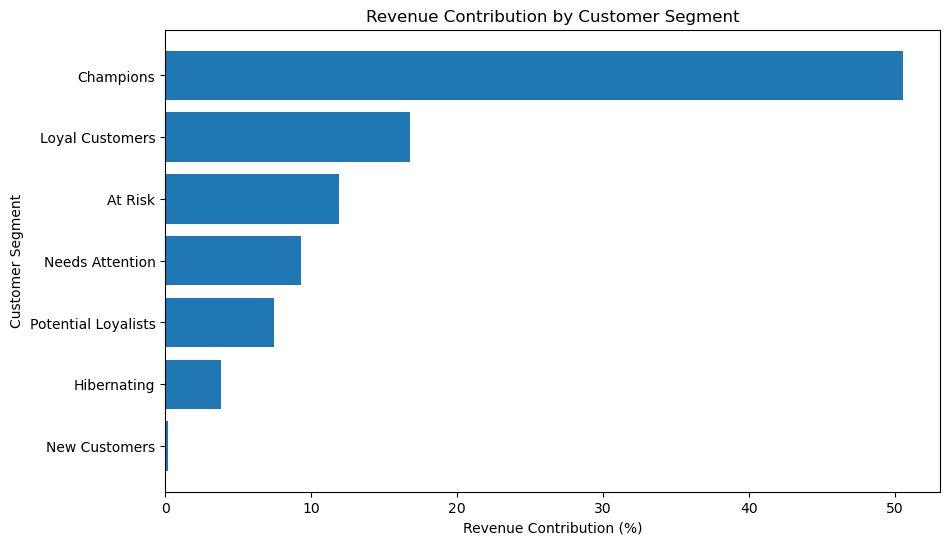

In [53]:
revenue_plot = (
    segment_analysis
    .sort_values(
        "revenue_percentage"
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    revenue_plot["segment"],
    revenue_plot["revenue_percentage"]
)

plt.xlabel(
    "Revenue Contribution (%)"
)

plt.ylabel(
    "Customer Segment"
)

plt.title(
    "Revenue Contribution by Customer Segment"
)

plt.show()

Customer Count vs Revenue

In [54]:
segment_share = (
    segment_analysis[
        [
            "segment",
            "customer_percentage",
            "revenue_percentage"
        ]
    ]
    .copy()
)

segment_share

,segment,customer_percentage,revenue_percentage
1,Champions,22.655427,50.586734
3,Loyal Customers,12.908325,16.771594
0,At Risk,12.223393,11.939555
4,Needs Attention,15.542677,9.276453
6,Potential Loyalists,11.485774,7.448119
2,Hibernating,24.130664,3.802627
5,New Customers,1.053741,0.174919


Revenue per Customer

In [55]:
segment_analysis[
    "revenue_per_customer"
] = (
    segment_analysis[
        "total_monetary"
    ]
    /
    segment_analysis[
        "customers"
    ]
)

In [56]:
segment_analysis[
    [
        "segment",
        "customers",
        "total_monetary",
        "revenue_per_customer"
    ]
]

,segment,customers,total_monetary,revenue_per_customer
1,Champions,430,6046400050,1.406140e+07
3,Loyal Customers,245,2004631650,8.182170e+06
0,At Risk,232,1427080200,6.151208e+06
4,Needs Attention,295,1108771800,3.758548e+06
6,Potential Loyalists,218,890239500,4.083667e+06
2,Hibernating,458,454510500,9.923810e+05
5,New Customers,20,20907250,1.045362e+06


Ranking segment

In [57]:
segment_analysis[
    "revenue_rank"
] = (
    segment_analysis[
        "total_monetary"
    ]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)

In [58]:
segment_analysis[
    [
        "segment",
        "total_monetary",
        "revenue_percentage",
        "revenue_rank"
    ]
].sort_values("revenue_rank")

,segment,total_monetary,revenue_percentage,revenue_rank
1,Champions,6046400050,50.586734,1
3,Loyal Customers,2004631650,16.771594,2
0,At Risk,1427080200,11.939555,3
4,Needs Attention,1108771800,9.276453,4
6,Potential Loyalists,890239500,7.448119,5
2,Hibernating,454510500,3.802627,6
5,New Customers,20907250,0.174919,7


Sekarang gabungkan dengan Customer Master

In [59]:
customers = pd.read_csv(
    "../data/processed/customers_clean.csv",
    parse_dates=["registration_date"]
)

In [60]:
customers.head()

,customer_id,customer_name,gender,city,registration_date,province
0,CUST00001,Customer 0001,Male,Jakarta,2025-06-01,DKI Jakarta
1,CUST00002,Customer 0002,Female,Bekasi,2023-11-09,Jawa Barat
2,CUST00003,Customer 0003,Male,Yogyakarta,2025-04-19,DI Yogyakarta
3,CUST00004,Customer 0004,Male,Depok,2024-06-02,Jawa Barat
4,CUST00005,Customer 0005,Male,Semarang,2024-01-10,Jawa Tengah


Merge Customer dengan RFM

In [61]:
customer_segments = (
    customers
    .merge(
        rfm,
        on="customer_id",
        how="left",
        validate="one_to_one"
    )
)

In [62]:
customer_segments.head()

,customer_id,customer_name,gender,city,registration_date,province,last_purchase,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,rfm_total_score,segment
0,CUST00001,Customer 0001,Male,Jakarta,2025-06-01,DKI Jakarta,2025-12-13,19.0,27.0,14614700.0,4.0,5.0,5.0,455.0,14.0,Champions
1,CUST00002,Customer 0002,Female,Bekasi,2023-11-09,Jawa Barat,2025-12-13,19.0,16.0,11428800.0,4.0,4.0,5.0,445.0,13.0,Champions
2,CUST00003,Customer 0003,Male,Yogyakarta,2025-04-19,DI Yogyakarta,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CUST00004,Customer 0004,Male,Depok,2024-06-02,Jawa Barat,2025-05-29,217.0,6.0,3279850.0,1.0,2.0,3.0,123.0,6.0,Needs Attention
4,CUST00005,Customer 0005,Male,Semarang,2024-01-10,Jawa Tengah,2025-11-10,52.0,15.0,10582650.0,3.0,4.0,4.0,344.0,11.0,Loyal Customers


In [63]:
customer_segments.shape

(2000, 16)

In [64]:
customer_segments[
    "segment"
].isna().sum()

np.int64(102)

segment Never Purchased

In [65]:
customer_segments[
    "segment"
] = (
    customer_segments[
        "segment"
    ]
    .fillna(
        "Never Purchased"
    )
)

In [66]:
customer_segments[
    "monetary"
] = (
    customer_segments[
        "monetary"
    ]
    .fillna(0)
)

In [67]:
customer_segments[
    "frequency"
] = (
    customer_segments[
        "frequency"
    ]
    .fillna(0)
)

RFM Score untuk Never Purchased

In [68]:
never_purchased = (
    customer_segments[
        customer_segments["segment"]
        == "Never Purchased"
    ]
)

print(
    f"Never Purchased Customers: "
    f"{len(never_purchased):,}"
)

Never Purchased Customers: 102


In [69]:
never_purchased_pct = (
    len(never_purchased)
    / len(customer_segments)
    * 100
)

print(
    f"Percentage: "
    f"{never_purchased_pct:.2f}%"
)

Percentage: 5.10%


Analisis segment berdasarkan kota

In [70]:
segment_city = (
    customer_segments
    .groupby(
        [
            "segment",
            "city"
        ]
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),
        monetary=(
            "monetary",
            "sum"
        )
    )
    .reset_index()
)

In [71]:
segment_city.head(20)

,segment,city,customers,monetary
0,At Risk,Bandung,36,2.157782e+08
1,At Risk,Bekasi,22,1.278982e+08
2,At Risk,Depok,19,1.055931e+08
3,At Risk,Jakarta,65,3.734112e+08
4,At Risk,Makassar,8,3.859660e+07
5,At Risk,Medan,14,1.041294e+08
6,At Risk,Semarang,9,6.703855e+07
7,At Risk,Surabaya,32,2.243716e+08
8,At Risk,Tangerang,19,1.142935e+08
9,At Risk,Yogyakarta,8,5.596975e+07


Champions berdasarkan kota

In [72]:
champions_by_city = (
    customer_segments[
        customer_segments["segment"]
        == "Champions"
    ]
    .groupby("city")
    .agg(
        champions=(
            "customer_id",
            "nunique"
        ),
        monetary=(
            "monetary",
            "sum"
        )
    )
    .sort_values(
        "champions",
        ascending=False
    )
)

champions_by_city

,champions,monetary
city,,
Jakarta,112,1.590528e+09
Bandung,58,8.322564e+08
Surabaya,48,7.071753e+08
Tangerang,46,6.415622e+08
Depok,33,4.325475e+08
Bekasi,32,5.066413e+08
Makassar,30,4.096452e+08
Semarang,25,3.506424e+08
Yogyakarta,25,2.918982e+08


At Risk berdasarkan kota

In [73]:
at_risk_by_city = (
    customer_segments[
        customer_segments["segment"]
        == "At Risk"
    ]
    .groupby("city")
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),
        historical_value=(
            "monetary",
            "sum"
        )
    )
    .sort_values(
        "historical_value",
        ascending=False
    )
)

at_risk_by_city

,customers,historical_value
city,,
Jakarta,65,373411200.0
Surabaya,32,224371650.0
Bandung,36,215778150.0
Bekasi,22,127898250.0
Tangerang,19,114293500.0
Depok,19,105593100.0
Medan,14,104129450.0
Semarang,9,67038550.0
Yogyakarta,8,55969750.0


Analisis berdasarkan Gender

In [74]:
segment_gender = pd.crosstab(
    customer_segments["segment"],
    customer_segments["gender"]
)

segment_gender

gender,Female,Male,Unknown
segment,,,
At Risk,120,112,0
Champions,207,222,1
Hibernating,236,218,4
Loyal Customers,125,120,0
Needs Attention,146,148,1
Never Purchased,36,65,1
New Customers,9,11,0
Potential Loyalists,103,114,1


Strategy Mapping

In [75]:
strategy_map = {

    "Champions":
        "Retain, VIP rewards, referral",

    "Loyal Customers":
        "Cross-sell, upsell, loyalty rewards",

    "Potential Loyalists":
        "Encourage repeat purchase",

    "New Customers":
        "Welcome and second-purchase campaign",

    "Needs Attention":
        "Personalized engagement",

    "At Risk":
        "Win-back and reactivation",

    "Hibernating":
        "Low-cost re-engagement",

    "Never Purchased":
        "First-purchase conversion"
}

In [77]:
customer_segments[
    "recommended_strategy"
] = (
    customer_segments[
        "segment"
    ]
    .map(strategy_map)
)

In [78]:
customer_segments[
    [
        "customer_id",
        "segment",
        "recommended_strategy"
    ]
].head(20)

,customer_id,segment,recommended_strategy
0,CUST00001,Champions,"Retain, VIP rewards, referral"
1,CUST00002,Champions,"Retain, VIP rewards, referral"
2,CUST00003,Never Purchased,First-purchase conversion
3,CUST00004,Needs Attention,Personalized engagement
4,CUST00005,Loyal Customers,"Cross-sell, upsell, loyalty rewards"
5,CUST00006,Potential Loyalists,Encourage repeat purchase
6,CUST00007,Needs Attention,Personalized engagement
7,CUST00008,Needs Attention,Personalized engagement
8,CUST00009,Hibernating,Low-cost re-engagement
9,CUST00010,Hibernating,Low-cost re-engagement


Tambahkan Priority

In [79]:
priority_map = {
    "Champions": "High",
    "Loyal Customers": "High",
    "Potential Loyalists": "Medium",
    "New Customers": "Medium",
    "Needs Attention": "Medium",
    "At Risk": "High",
    "Hibernating": "Low",
    "Never Purchased": "Medium"
}

In [81]:
customer_segments[
    "marketing_priority"
] = (
    customer_segments[
        "segment"
    ]
    .map(priority_map)
)

Final Segment Validation

In [82]:
customer_segments[
    "segment"
].isna().sum()

np.int64(0)

In [83]:
customer_segments[
    "customer_id"
].duplicated().sum()

np.int64(0)

Validasi semua customer terwakili

In [84]:
assert (
    len(customer_segments)
    == len(customers)
)

In [85]:
assert (
    customer_segments[
        "customer_id"
    ].nunique()
    == customers[
        "customer_id"
    ].nunique()
)

Validasi Monetary

In [86]:
purchasing_customers = (
    customer_segments[
        customer_segments["segment"]
        != "Never Purchased"
    ]
)

In [87]:
segment_monetary = (
    purchasing_customers[
        "monetary"
    ].sum()
)

rfm_monetary = (
    rfm["monetary"]
    .sum()
)

print(
    f"Customer Segment Monetary : "
    f"Rp{segment_monetary:,.0f}"
)

print(
    f"RFM Monetary              : "
    f"Rp{rfm_monetary:,.0f}"
)

Customer Segment Monetary : Rp11,952,540,950
RFM Monetary              : Rp11,952,540,950


Final Segment Distribution

In [88]:
final_segment_distribution = (
    customer_segments
    .groupby("segment")
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        total_monetary=(
            "monetary",
            "sum"
        )
    )
    .reset_index()
)

In [89]:
final_segment_distribution[
    "customer_percentage"
] = (
    final_segment_distribution[
        "customers"
    ]
    / len(customer_segments)
    * 100
)

Menghitung Revenue Contribution per Segment

In [94]:
total_revenue = customer_segments["monetary"].sum()

final_segment_distribution["revenue_percentage"] = (
    final_segment_distribution["total_monetary"]
    / total_revenue
    * 100
)

final_segment_distribution = (
    final_segment_distribution
    .sort_values("total_monetary", ascending=False)
    .reset_index(drop=True)
)

final_segment_distribution

,segment,customers,total_monetary,customer_percentage,revenue_percentage
0,Champions,430,6.046400e+09,21.50,50.586734
1,Loyal Customers,245,2.004632e+09,12.25,16.771594
2,At Risk,232,1.427080e+09,11.60,11.939555
3,Needs Attention,295,1.108772e+09,14.75,9.276453
4,Potential Loyalists,218,8.902395e+08,10.90,7.448119
5,Hibernating,458,4.545105e+08,22.90,3.802627
6,New Customers,20,2.090725e+07,1.00,0.174919
7,Never Purchased,102,0.000000e+00,5.10,0.000000


Mengukur Customer Value per Segment

In [95]:
final_segment_distribution["avg_customer_value"] = (
    final_segment_distribution["total_monetary"]
    / final_segment_distribution["customers"]
)

In [96]:
final_segment_distribution[
    [
        "segment",
        "customers",
        "total_monetary",
        "avg_customer_value",
        "revenue_percentage"
    ]
]

,segment,customers,total_monetary,avg_customer_value,revenue_percentage
0,Champions,430,6.046400e+09,1.406140e+07,50.586734
1,Loyal Customers,245,2.004632e+09,8.182170e+06,16.771594
2,At Risk,232,1.427080e+09,6.151208e+06,11.939555
3,Needs Attention,295,1.108772e+09,3.758548e+06,9.276453
4,Potential Loyalists,218,8.902395e+08,4.083667e+06,7.448119
5,Hibernating,458,4.545105e+08,9.923810e+05,3.802627
6,New Customers,20,2.090725e+07,1.045362e+06,0.174919
7,Never Purchased,102,0.000000e+00,0.000000e+00,0.000000


Visualisasi Customer Share vs Revenue Share

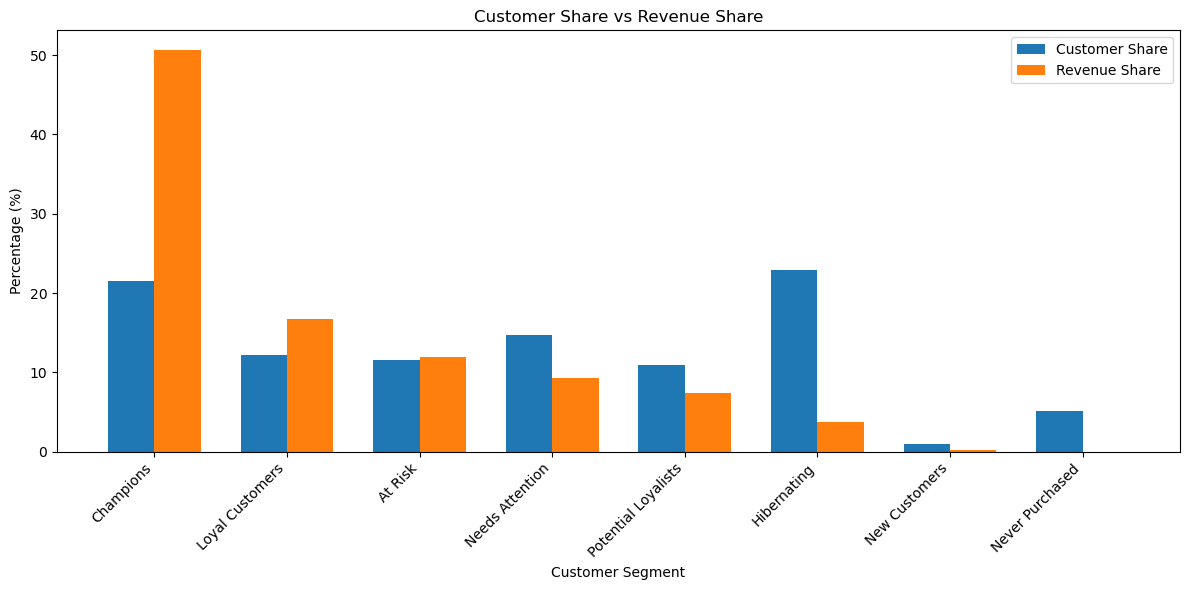

In [97]:
import matplotlib.pyplot as plt
import numpy as np

plot_data = final_segment_distribution.copy()

x = np.arange(len(plot_data))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    plot_data["customer_percentage"],
    width,
    label="Customer Share"
)

plt.bar(
    x + width / 2,
    plot_data["revenue_percentage"],
    width,
    label="Revenue Share"
)

plt.xticks(
    x,
    plot_data["segment"],
    rotation=45,
    ha="right"
)

plt.xlabel("Customer Segment")
plt.ylabel("Percentage (%)")
plt.title("Customer Share vs Revenue Share")
plt.legend()
plt.tight_layout()
plt.show()

Business Insight Summary

In [98]:
top_segment = final_segment_distribution.iloc[0]

print("=== CUSTOMER SEGMENTATION INSIGHTS ===")

print(
    f"Total Registered Customers: "
    f"{len(customer_segments):,}"
)

print(
    f"Total Historical Revenue: "
    f"Rp{total_revenue:,.0f}"
)

print(
    f"Highest Revenue Segment: "
    f"{top_segment['segment']}"
)

print(
    f"Revenue Contribution: "
    f"{top_segment['revenue_percentage']:.2f}%"
)

=== CUSTOMER SEGMENTATION INSIGHTS ===
Total Registered Customers: 2,000
Total Historical Revenue: Rp11,952,540,950
Highest Revenue Segment: Champions
Revenue Contribution: 50.59%


In [99]:
largest_segment = (
    final_segment_distribution
    .sort_values("customers", ascending=False)
    .iloc[0]
)

print(
    f"Largest Customer Segment: "
    f"{largest_segment['segment']}"
)

print(
    f"Customer Count: "
    f"{largest_segment['customers']:,}"
)

Largest Customer Segment: Hibernating
Customer Count: 458


Membuat Data Validation Akhir

In [100]:
validation_results = {
    "duplicate_customer_id":
        customer_segments["customer_id"].duplicated().sum(),

    "missing_customer_id":
        customer_segments["customer_id"].isna().sum(),

    "missing_segment":
        customer_segments["segment"].isna().sum(),

    "negative_frequency":
        (customer_segments["frequency"] < 0).sum(),

    "negative_monetary":
        (customer_segments["monetary"] < 0).sum(),

    "missing_strategy":
        customer_segments["recommended_strategy"].isna().sum(),

    "missing_priority":
        customer_segments["marketing_priority"].isna().sum()
}

validation_report = pd.DataFrame(
    validation_results.items(),
    columns=["validation_rule", "invalid_records"]
)

validation_report

,validation_rule,invalid_records
0,duplicate_customer_id,0
1,missing_customer_id,0
2,missing_segment,0
3,negative_frequency,0
4,negative_monetary,0
5,missing_strategy,0
6,missing_priority,0


In [101]:
assert (validation_report["invalid_records"] == 0).all()

assert len(customer_segments) == len(customers)

assert np.isclose(
    customer_segments["monetary"].sum(),
    rfm["monetary"].sum()
)

print("All customer segmentation validations passed.")

All customer segmentation validations passed.


Export Customer Segmentation Dataset

In [102]:
from pathlib import Path

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

customer_segments.to_csv(
    output_dir / "customer_segments.csv",
    index=False
)

In [103]:
final_segment_distribution.to_csv(
    output_dir / "segment_summary.csv",
    index=False
)

Validasi File Export

In [104]:
segments_test = pd.read_csv(
    "../data/processed/customer_segments.csv"
)

summary_test = pd.read_csv(
    "../data/processed/segment_summary.csv"
)

print("Customer Segments:", segments_test.shape)
print("Segment Summary:", summary_test.shape)

Customer Segments: (2000, 18)
Segment Summary: (8, 6)


In [105]:
segments_test.head()

,customer_id,customer_name,gender,city,registration_date,province,last_purchase,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,rfm_total_score,segment,recommended_strategy,marketing_priority
0,CUST00001,Customer 0001,Male,Jakarta,2025-06-01,DKI Jakarta,2025-12-13,19.0,27.0,14614700.0,4.0,5.0,5.0,455.0,14.0,Champions,"Retain, VIP rewards, referral",High
1,CUST00002,Customer 0002,Female,Bekasi,2023-11-09,Jawa Barat,2025-12-13,19.0,16.0,11428800.0,4.0,4.0,5.0,445.0,13.0,Champions,"Retain, VIP rewards, referral",High
2,CUST00003,Customer 0003,Male,Yogyakarta,2025-04-19,DI Yogyakarta,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,Never Purchased,First-purchase conversion,Medium
3,CUST00004,Customer 0004,Male,Depok,2024-06-02,Jawa Barat,2025-05-29,217.0,6.0,3279850.0,1.0,2.0,3.0,123.0,6.0,Needs Attention,Personalized engagement,Medium
4,CUST00005,Customer 0005,Male,Semarang,2024-01-10,Jawa Tengah,2025-11-10,52.0,15.0,10582650.0,3.0,4.0,4.0,344.0,11.0,Loyal Customers,"Cross-sell, upsell, loyalty rewards",High


In [106]:
summary_test.head()

,segment,customers,total_monetary,customer_percentage,revenue_percentage,avg_customer_value
0,Champions,430,6.046400e+09,21.50,50.586734,1.406140e+07
1,Loyal Customers,245,2.004632e+09,12.25,16.771594,8.182170e+06
2,At Risk,232,1.427080e+09,11.60,11.939555,6.151208e+06
3,Needs Attention,295,1.108772e+09,14.75,9.276453,3.758548e+06
4,Potential Loyalists,218,8.902395e+08,10.90,7.448119,4.083667e+06


Kesimpulan

# Customer Segmentation Analysis Summary

## Tujuan Analisis

Customer Segmentation dilakukan untuk mengelompokkan customer
berdasarkan perilaku transaksi menggunakan metode RFM.

## Metodologi

Tahapan analisis:

1. Menggunakan dataset RFM hasil Notebook 03.
2. Menentukan business rules segmentasi.
3. Mengelompokkan customer berdasarkan RFM Score.
4. Menghitung jumlah customer setiap segment.
5. Mengukur kontribusi historical revenue.
6. Menganalisis rata-rata Recency, Frequency, dan Monetary.
7. Menggabungkan hasil segmentasi dengan customer master.
8. Mengidentifikasi customer yang belum pernah bertransaksi.
9. Menyusun strategi marketing berdasarkan karakteristik segment.
10. Melakukan validasi dan mengekspor hasil.

## Hasil Analisis

- Total customer: [ISI HASIL]
- Segment terbesar: [ISI HASIL]
- Segment dengan kontribusi revenue terbesar: [ISI HASIL]
- Revenue contribution segment terbesar: [ISI HASIL]
- Jumlah customer At Risk: [ISI HASIL]
- Jumlah customer Never Purchased: [ISI HASIL]

## Kesimpulan

RFM Analysis membantu mengidentifikasi perbedaan aktivitas dan
nilai historis customer.

Hasil segmentasi dapat digunakan sebagai dasar untuk merancang
strategi retention, loyalty, reactivation, dan first-purchase campaign.

## Output

- customer_segments.csv
- segment_summary.csv

## Next Step

Power BI Dashboard Development.